<a href="https://colab.research.google.com/github/student-abdulrehman/3-days-analytics-workshop/blob/main/final_student_habit_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of students (rows)
n = 100

# Generate synthetic data
data = {
    "student_id": np.arange(1, n+1),
    "age": np.random.randint(18, 25, size=n),
    "gender": np.random.choice(["Male", "Female"], size=n),
    "study_hours_per_day": np.random.randint(1, 6, size=n),  # 1–5 hours
    "social_media_hours": np.random.randint(0, 6, size=n),   # 0–5 hours
    "netflix_hours": np.random.randint(0, 5, size=n),        # 0–4 hours
    "part_time_job": np.random.choice(["Yes", "No"], size=n),
    "attendance_percentage": np.random.randint(50, 101, size=n),  # 50–100%
    "sleep_hours": np.random.randint(5, 9, size=n),          # 5–8 hours
    "diet_quality": np.random.choice(["Poor", "Average", "Good"], size=n),
    "exercise_frequency": np.random.randint(0, 5, size=n),   # 0–4 times/week
    "parental_education_level": np.random.choice(["High School", "Graduate", "Postgraduate"], size=n),
    "internet_quality": np.random.choice(["Low", "Medium", "High"], size=n),
    "mental_health_rating": np.random.randint(1, 11, size=n),  # 1–10 scale
    "extracurricular_participation": np.random.choice(["Yes", "No"], size=n),
    "exam_score": np.random.randint(40, 101, size=n)          # 40–100 marks
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("student_habits_performance.csv", index=False)

print("✅ student_habits_performance.csv created successfully!")
df.head()

✅ student_habits_performance.csv created successfully!


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,1,24,Female,5,3,4,No,58,7,Good,4,Graduate,Medium,1,Yes,76
1,2,21,Female,3,1,0,No,73,5,Average,4,Postgraduate,Medium,6,No,93
2,3,22,Male,5,0,2,No,84,8,Good,1,High School,Low,6,No,60
3,4,24,Female,4,3,1,No,98,6,Poor,2,High School,Medium,4,No,53
4,5,20,Male,5,3,0,No,84,7,Poor,2,Postgraduate,Low,8,No,70


In [30]:
# Title: Create dataset student_habits_performance.csv

import pandas as pd
import numpy as np

np.random.seed(42)
n = 300  # adjust rows as needed (>= 100 recommended)

df = pd.DataFrame({
    "student_id": np.arange(1, n+1),
    "age": np.random.randint(18, 25, size=n),
    "gender": np.random.choice(["Male", "Female"], size=n),
    "study_hours_per_day": np.random.randint(1, 6, size=n),           # 1–5 hours
    "social_media_hours": np.random.randint(0, 6, size=n),             # 0–5 hours
    "netflix_hours": np.random.randint(0, 5, size=n),                  # 0–4 hours
    "part_time_job": np.random.choice(["Yes", "No"], size=n),
    "attendance_percentage": np.random.randint(50, 101, size=n),       # 50–100%
    "sleep_hours": np.random.randint(5, 9, size=n),                    # 5–8 hours
    "diet_quality": np.random.choice(["Poor", "Average", "Good"], size=n),
    "exercise_frequency": np.random.randint(0, 5, size=n),             # 0–4 times/week
    "parental_education_level": np.random.choice(["High School", "Graduate", "Postgraduate"], size=n),
    "internet_quality": np.random.choice(["Low", "Medium", "High"], size=n),
    "mental_health_rating": np.random.randint(1, 11, size=n),          # 1–10
    "extracurricular_participation": np.random.choice(["Yes", "No"], size=n),
    "exam_score": np.random.randint(40, 101, size=n)                   # 40–100
})

df.to_csv("student_habits_performance.csv", index=False)
print("student_habits_performance.csv created.")

student_habits_performance.csv created.


In [31]:
# Title: Setup and data loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set(style="whitegrid", context="notebook")
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv("student_habits_performance.csv")

print("Shape:", df.shape)
df.head()

Shape: (300, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,1,24,Male,1,4,1,Yes,54,6,Average,2,Graduate,Low,3,No,72
1,2,21,Female,5,4,0,No,97,6,Average,2,High School,Low,1,No,94
2,3,22,Male,5,3,1,Yes,75,6,Average,3,Graduate,High,8,No,97
3,4,24,Male,1,5,2,No,67,6,Average,4,Graduate,Low,3,No,46
4,5,20,Male,5,0,4,No,55,7,Good,3,High School,High,8,No,91


In [32]:
# Title: Data preprocessing(DP):

# Clean column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Drop identifier
if 'student_id' in df.columns:
    df = df.drop(columns=['student_id'])

# Target
target = "exam_score"

# Feature sets
numeric_features = [
    'age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
    'attendance_percentage', 'sleep_hours', 'exercise_frequency',
    'mental_health_rating'
]
categorical_features = [
    'gender', 'part_time_job', 'diet_quality', 'parental_education_level',
    'internet_quality', 'extracurricular_participation'
]

# Clip ranges
df['attendance_percentage'] = df['attendance_percentage'].clip(0, 100)
df['study_hours_per_day'] = df['study_hours_per_day'].clip(lower=0)
df['sleep_hours'] = df['sleep_hours'].clip(lower=0, upper=24)
df['social_media_hours'] = df['social_media_hours'].clip(lower=0, upper=24)
df['netflix_hours'] = df['netflix_hours'].clip(lower=0, upper=24)
df['exercise_frequency'] = df['exercise_frequency'].clip(lower=0)
df['mental_health_rating'] = df['mental_health_rating'].clip(1, 10)

# Split X/y
X = df.drop(columns=[target])
y = df[target]

# Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (240, 14) Test: (60, 14)


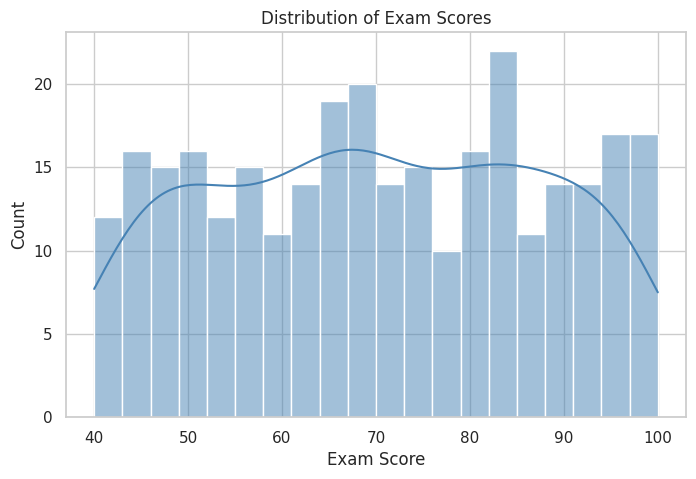

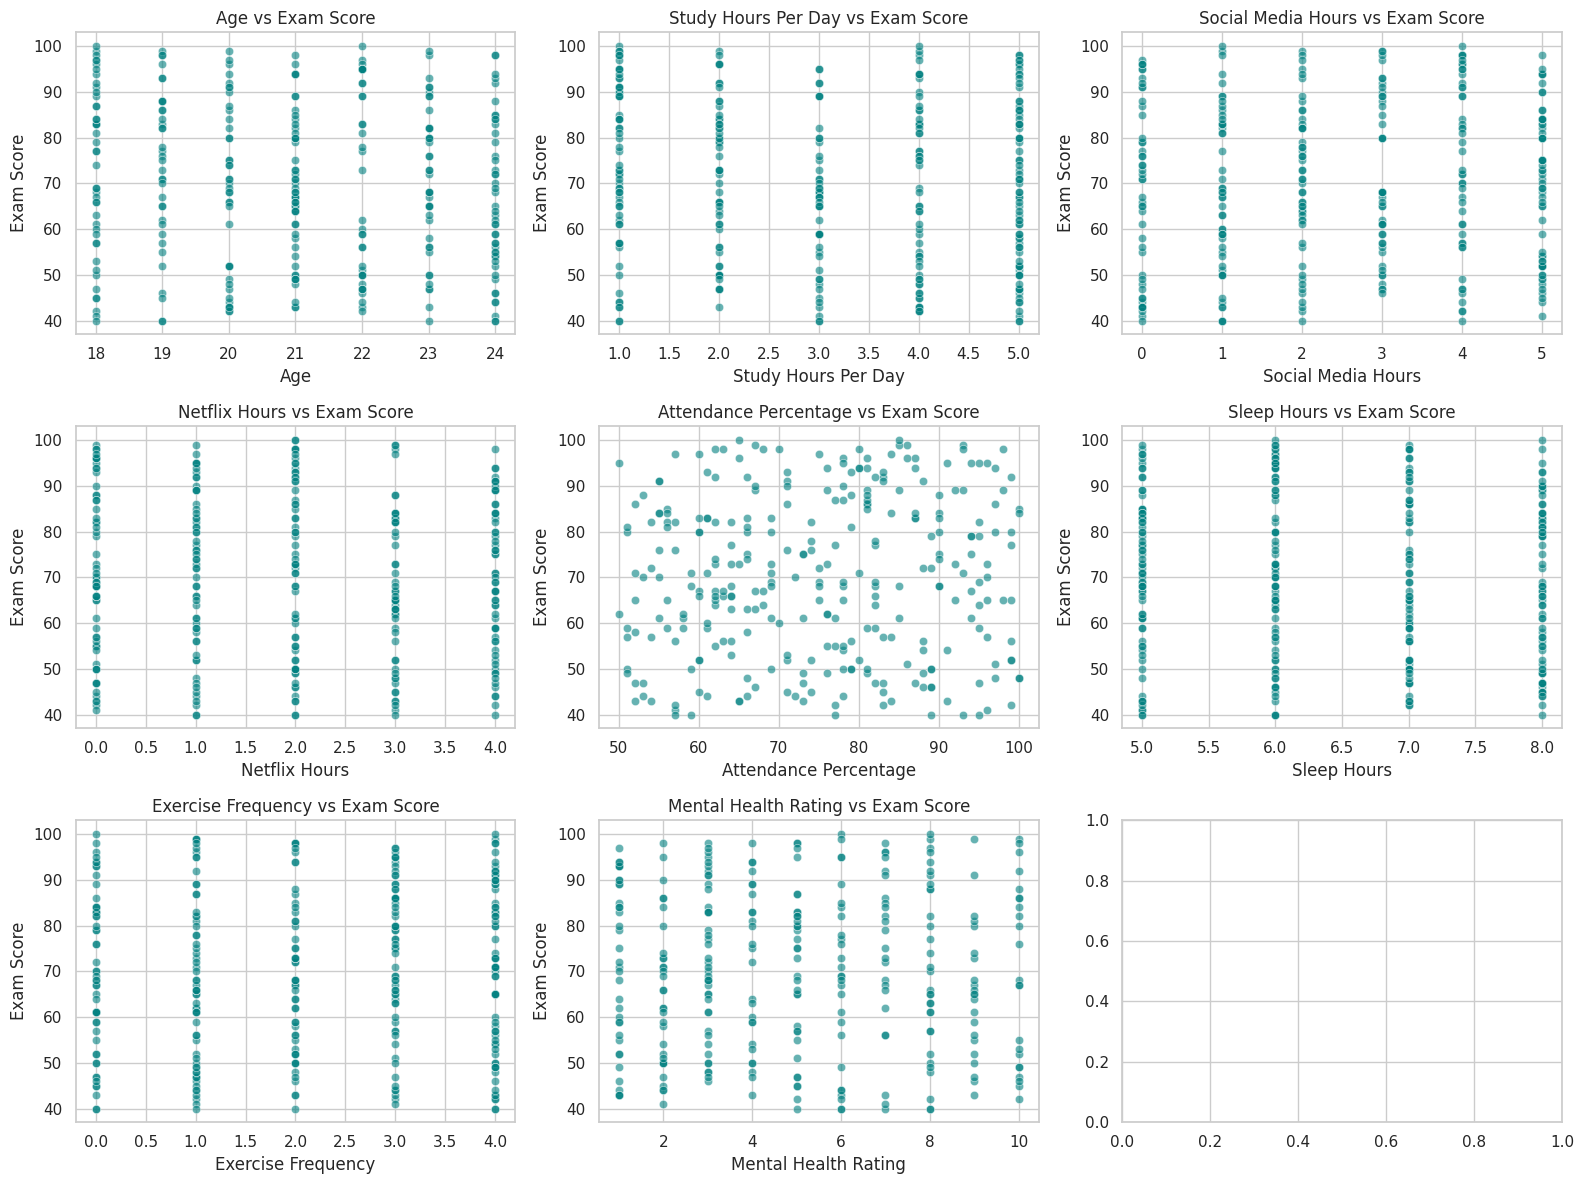

/tmp/ipython-input-4037674866.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='exam_score', ax=axes[i], palette='Set2')
/tmp/ipython-input-4037674866.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='exam_score', ax=axes[i], palette='Set2')
/tmp/ipython-input-4037674866.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='exam_score', ax=axes[i], palette='Set2')
/tmp/ipython-input-4037674866.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

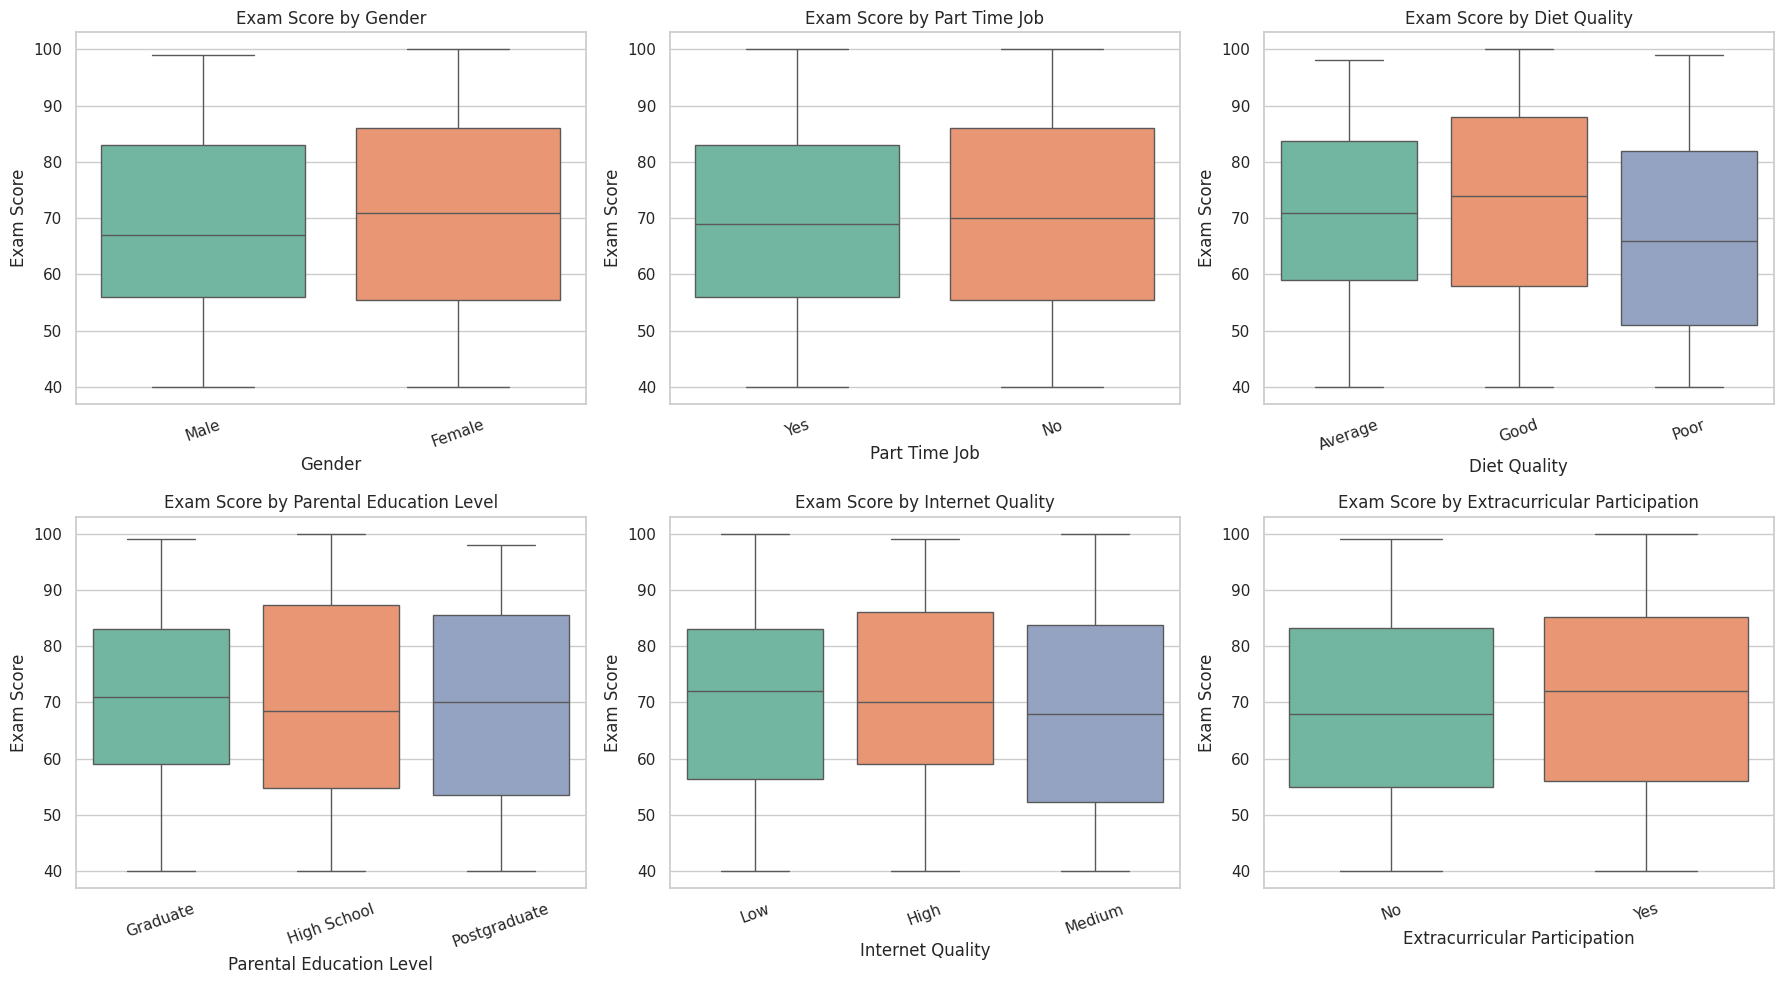

In [33]:
# Title: Exploratory data analysis (EDA)

import matplotlib.ticker as mticker

# Exam score distribution
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], bins=20, kde=True, color='steelblue')
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()

# Scatter: numeric features vs exam_score
num_cols = numeric_features
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.scatterplot(data=df, x=col, y='exam_score', alpha=0.6, ax=axes[i], color='teal')
    axes[i].set_title(f"{col.replace('_',' ').title()} vs Exam Score")
    axes[i].set_xlabel(col.replace('_',' ').title())
    axes[i].set_ylabel("Exam Score")
plt.tight_layout()
plt.show()

# Box plots for categorical features
cat_cols = categorical_features
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18,10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='exam_score', ax=axes[i], palette='Set2')
    axes[i].set_title(f"Exam Score by {col.replace('_',' ').title()}")
    axes[i].set_xlabel(col.replace('_',' ').title())
    axes[i].set_ylabel("Exam Score")
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

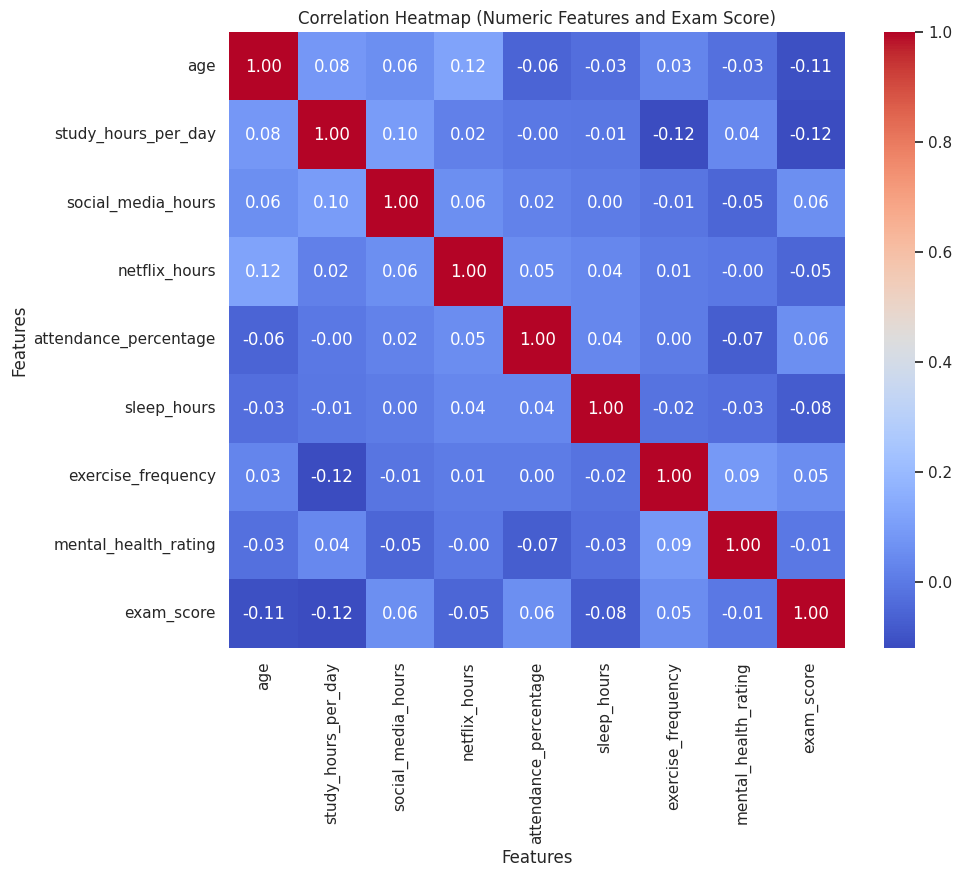

Correlation with Exam Score:
 attendance_percentage    0.057366
social_media_hours       0.056950
exercise_frequency       0.052726
mental_health_rating    -0.005039
netflix_hours           -0.053526
sleep_hours             -0.078081
age                     -0.109687
study_hours_per_day     -0.120036
Name: exam_score, dtype: float64


In [34]:
# Title: Correlation analysis

corr = df[numeric_features + [target]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap (Numeric Features and Exam Score)")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

# Numeric correlation ranking
corr_target = corr[target].drop(target).sort_values(ascending=False)
print("Correlation with Exam Score:\n", corr_target)

Linear Regression - MAE: 16.00188428194708
Linear Regression - R^2: -0.1303819669911921
Lasso - MAE: 15.94339158101454
Lasso - R^2: -0.11618152938057391
Random Forest - MAE: 15.696777777777779
Random Forest - R^2: -0.059627240039357154


/tmp/ipython-input-2501223708.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x='importance', y='feature', palette='viridis')


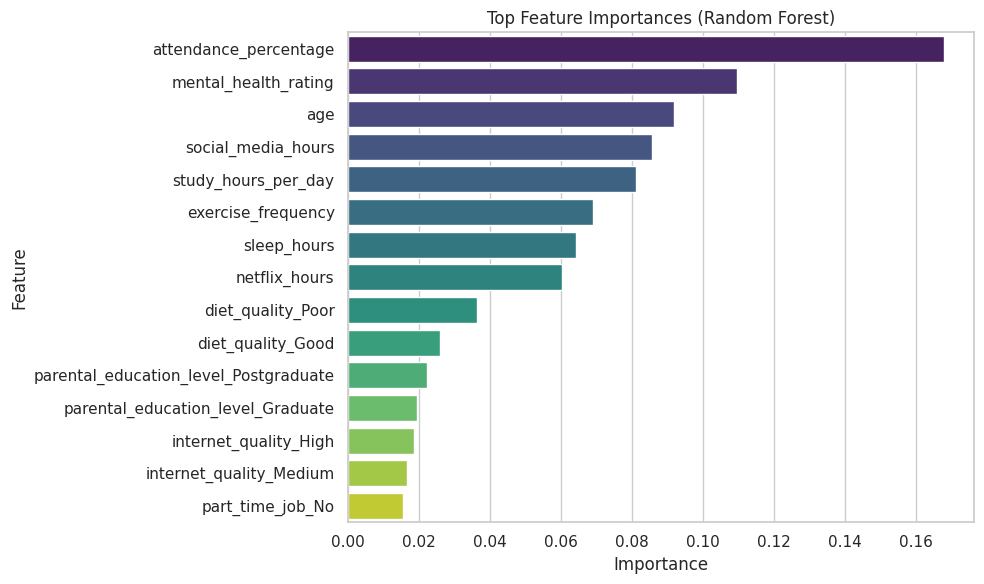

,feature,importance
4,attendance_percentage,0.167901
7,mental_health_rating,0.109630
0,age,0.091848
2,social_media_hours,0.085757
1,study_hours_per_day,0.081074
6,exercise_frequency,0.069150
5,sleep_hours,0.064187
3,netflix_hours,0.060184
14,diet_quality_Poor,0.036479
13,diet_quality_Good,0.026007


In [35]:
# Title: Modeling

from sklearn.metrics import mean_squared_error

# Linear Regression
linreg = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', LinearRegression())])
linreg.fit(X_train, y_train)
y_pred_lr = linreg.predict(X_test)
print("Linear Regression - MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression - R^2:", r2_score(y_test, y_pred_lr))

# Lasso Regression
lasso = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', Lasso(alpha=0.05, max_iter=10000, random_state=42))])
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("Lasso - MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("Lasso - R^2:", r2_score(y_test, y_pred_lasso))

# Random Forest
rf = Pipeline(steps=[('preprocessor', preprocessor),
                     ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest - MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest - R^2:", r2_score(y_test, y_pred_rf))

# Feature importances from RF
ohe = rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = numeric_features + cat_feature_names

importances = rf.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
           .sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature', palette='viridis')
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

feat_imp.head(20)

In [36]:
# Title: Findings and conclusion

# Categorical medians
print("Median exam score by category:")
for col in ['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
            'internet_quality', 'extracurricular_participation']:
    med = df.groupby(col)['exam_score'].median().sort_values(ascending=False)
    print(f"\n{col.replace('_',' ').title()}:\n{med}")

summary = """
Key findings:
- Study habits and continuity: Higher study_hours_per_day and attendance_percentage align with higher exam_score.
- Wellbeing: Better sleep_hours and mental_health_rating associate with improved performance.
- Distractions: More social_media_hours and netflix_hours tend to relate to lower exam_score.
- Physical and environment: Exercise_frequency and diet_quality show positive but moderate associations; better internet_quality helps consistency.
- Model signals: Random Forest highlights attendance_percentage, study_hours_per_day, sleep_hours, mental_health_rating, and social_media_hours as influential.

Recommendations:
- Establish consistent study routines (focused 2–4 hours daily) with active learning (spaced repetition, practice tests).
- Implement digital hygiene: limit social media/streaming during study blocks via timers/blockers.
- Promote sleep hygiene and mental health support (regular sleep schedule, counseling access).
- Encourage physical activity and balanced diet to sustain energy and focus.
- Provide reliable study environments (internet access, quiet spaces) and extracurriculars that build discipline.
- Offer targeted support for at-risk patterns (low attendance, high distractions) via mentoring and study skills workshops.

Conclusion:
Academic performance is multifactorial. The strongest levers are attendance, structured study time, healthy sleep, and mental wellbeing, supported by reduced digital distractions and a stable learning environment.
"""
print(summary)

Median exam score by category:

Gender:
gender
Female    71.0
Male      67.0
Name: exam_score, dtype: float64

Part Time Job:
part_time_job
No     70.0
Yes    69.0
Name: exam_score, dtype: float64

Diet Quality:
diet_quality
Good       74.0
Average    71.0
Poor       66.0
Name: exam_score, dtype: float64

Parental Education Level:
parental_education_level
Graduate        71.0
Postgraduate    70.0
High School     68.5
Name: exam_score, dtype: float64

Internet Quality:
internet_quality
Low       72.0
High      70.0
Medium    68.0
Name: exam_score, dtype: float64

Extracurricular Participation:
extracurricular_participation
Yes    72.0
No     68.0
Name: exam_score, dtype: float64

Key findings:
- Study habits and continuity: Higher study_hours_per_day and attendance_percentage align with higher exam_score.
- Wellbeing: Better sleep_hours and mental_health_rating associate with improved performance.
- Distractions: More social_media_hours and netflix_hours tend to relate to lower exam_sco